In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install gdown


In [3]:
!gdown 1VGm-hWxktQp978mc6rEbkn9eDxo7zBRZ

# https://drive.google.com/file/d/1VGm-hWxktQp978mc6rEbkn9eDxo7zBRZ/view?usp=drive_link

Downloading...
From (original): https://drive.google.com/uc?id=1VGm-hWxktQp978mc6rEbkn9eDxo7zBRZ
From (redirected): https://drive.google.com/uc?id=1VGm-hWxktQp978mc6rEbkn9eDxo7zBRZ&confirm=t&uuid=c082f44c-f361-40d7-ab02-cf3ea2fb5204
To: /content/suitesparse_kaggle_export.zip
100% 1.72G/1.72G [00:27<00:00, 63.1MB/s]


In [4]:
# @title
!unzip suitesparse_kaggle_export.zip


Streaming output truncated to the last 5000 lines.
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1642.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1643.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1644.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1645.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1646.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1647.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1648.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1649.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_165.txt  
  inflating: suitespars

In [5]:
!pip install ssgetpy -q


In [6]:
import json
import ssgetpy
from pathlib import Path

data_dir = Path("suitesparse_mtx")

# Load the saved metadata
with open("suitesparse_selected.json") as f:
    meta = json.load(f)

print("Matrices listed in JSON:", len(meta))

# Rebuild selected list exactly as in kaggle
selected = []
for item in meta:
    g = item["group"]
    n = item["name"]
    try:
        # Fetch the exact matrix entry from SuiteSparse DB metadata
        m = ssgetpy.search(group=g, name=n, limit=1)[0]
        selected.append(m)
    except:
        print("Could not find:", g, n)

print("Reconstructed selected list:", len(selected))


Matrices listed in JSON: 1765
Reconstructed selected list: 1765


In [7]:
from pathlib import Path
import scipy.io
import scipy.sparse as sp
import numpy as np

data_dir = Path("suitesparse_mtx")

def load_matrix_metadata(m):
    """
    Given an ssgetpy Matrix object m (with .group and .name),
    recursively find a .mtx file under suitesparse_mtx/group/name/,
    load it as SciPy CSR (float64), and return it.
    """
    base_dir = data_dir / m.group / m.name

    if not base_dir.exists():
        print(f"[WARN] Directory not found for {m.group}/{m.name}: {base_dir}")
        return None

    # Recursively search for any .mtx file
    mtx_file = None
    for f in base_dir.rglob("*.mtx"):
        mtx_file = f
        break  # first match

    if mtx_file is None:
        print(f"[WARN] No .mtx file found under {base_dir}")
        return None

    print(f"Loading {m.group}/{m.name} from {mtx_file.relative_to(data_dir)}")
    A = scipy.io.mmread(str(mtx_file))
    A = A.tocsr().astype(np.float64)   # ensure CSR float64

    print(f"  shape: {A.shape}, nnz: {A.nnz}, dtype: {A.dtype}")
    return A

# 🔍 Test on first 3 matrices
print("Testing loader on a few matrices...")
for m in selected[:3]:
    A = load_matrix_metadata(m)
    print("-" * 60)


Testing loader on a few matrices...
Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
------------------------------------------------------------
Loading HB/494_bus from HB/494_bus/494_bus/494_bus.mtx
  shape: (494, 494), nnz: 1666, dtype: float64
------------------------------------------------------------
Loading HB/662_bus from HB/662_bus/662_bus/662_bus.mtx
  shape: (662, 662), nnz: 2474, dtype: float64
------------------------------------------------------------


In [8]:
import cupy as cp
import time

def scipy_to_cupy_csr(A, dtype=cp.float64):
    A = A.tocsr()
    data = cp.asarray(A.data, dtype=dtype)
    indices = cp.asarray(A.indices, dtype=cp.int32)
    indptr = cp.asarray(A.indptr, dtype=cp.int32)
    return cp.sparse.csr_matrix((data, indices, indptr), shape=A.shape)

def gpu_reference_spmv(A, n_runs=10):
    """
    Class 0: Pure FP64 Baseline.
    Returns: A_gpu, x_ref, y_ref, avg_time
    """
    # 1) Move to GPU in float64
    A64_gpu = scipy_to_cupy_csr(A, dtype=cp.float64)
    n = A.shape[1]
    x_ref = cp.random.randn(n, dtype=cp.float64)

    # 2) Warm-up
    _ = A64_gpu @ x_ref
    cp.cuda.Stream.null.synchronize()

    # 3) Timed runs
    t0 = time.time()
    for _ in range(n_runs):
        y_ref = A64_gpu @ x_ref
    cp.cuda.Stream.null.synchronize()

    avg_t = (time.time() - t0) / n_runs
    return A64_gpu, x_ref, y_ref, avg_t






In [9]:
def get_adaptive_threshold(A, f=0.1):
    """
    Calculate threshold r = f * mean(|A|).
    Reference: Paper Section III-A.
    """
    data_abs = np.abs(A.data)
    if data_abs.size == 0: return 1e-9
    return f * np.mean(data_abs)

def eval_rowwise_split(A, x_ref, y_ref, n_runs=10):
    """
    Class 1: Row-wise Split (Paper Method).
    A row is 'Low Precision' (FP32) only if p=99% of its values are < threshold.
    Otherwise, the whole row is kept in FP64.
    """
    # 1. Calculate Adaptive Threshold
    thresh = get_adaptive_threshold(A, f=0.1)
    p = 0.90  # Paper recommendation for "safe" rows

    A_csr = A.tocsr()

    # 2. Analyze Rows (CPU)
    # Count 'unsafe' values per row
    unsafe_mask = np.abs(A_csr.data) >= thresh

    # Create a wrapper matrix to sum unsafe counts per row efficiently
    A_unsafe = sp.csr_matrix((unsafe_mask.astype(int), A_csr.indices, A_csr.indptr), shape=A.shape)

    row_unsafe_counts = np.array(A_unsafe.sum(axis=1)).flatten()
    row_total_counts = np.diff(A_csr.indptr)
    row_total_counts[row_total_counts == 0] = 1 # avoid div/0

    # Calculate fraction of SAFE values
    safe_frac = 1.0 - (row_unsafe_counts / row_total_counts)

    # Identify Low (FP32) and High (FP64) rows
    lo_mask = safe_frac >= p
    hi_mask = ~lo_mask

    # 3. Disqualification Check
    # If the split results in an empty matrix (all FP64 or all FP32),
    # this strategy is invalid for "Mixed" precision. Return infinite time.
    if lo_mask.sum() == 0 or hi_mask.sum() == 0:
        return float('inf'), 0.0

    # 4. Build Split Matrices
    A_lo = A_csr[lo_mask, :]
    A_hi = A_csr[hi_mask, :]

    # 5. Move to GPU
    A_hi_gpu = scipy_to_cupy_csr(A_hi, dtype=cp.float64)
    A_lo_gpu = scipy_to_cupy_csr(A_lo, dtype=cp.float32)

    x64 = x_ref
    x32 = x_ref.astype(cp.float32)

    # 6. Warm-up
    _ = A_hi_gpu @ x64
    _ = A_lo_gpu @ x32
    cp.cuda.Stream.null.synchronize()

    # 7. Timed runs
    t0 = time.time()
    for _ in range(n_runs):
        y_hi = A_hi_gpu @ x64
        y_lo = A_lo_gpu @ x32
    cp.cuda.Stream.null.synchronize()

    avg_t = (time.time() - t0) / n_runs

    # 8. Reconstruct Result (CPU-side logic to combine rows)
    # We scatter the results back into the full vector
    y_full = cp.zeros_like(y_ref)
    hi_idx = np.where(hi_mask)[0]
    lo_idx = np.where(lo_mask)[0]

    if len(hi_idx) > 0: y_full[hi_idx] = y_hi
    if len(lo_idx) > 0: y_full[lo_idx] = y_lo.astype(cp.float64)

    err = cp.linalg.norm(y_full - y_ref) / cp.linalg.norm(y_ref)
    return avg_t, float(err)

In [10]:
import json
from tqdm.auto import tqdm

# RELAXATION 1: Remove the 1% speedup buffer
# If Row-wise is even 0.00001s faster, it takes the win.
# RELAXATION 2: Slight error tolerance bump (optional)
# Paper says mixed precision works for iterative solvers which fix small errors.
err_tol = 5e-3  # Keep 0.1% (Safe) or try 5e-3 (0.5%) if desperate

labels = {}
stats = {}
skipped_error = []

print("Running RELAXED Binary Tournament...")

for m in tqdm(selected, desc="Labeling"):
    name = f"{m.group}/{m.name}"
    try:
        A = load_matrix_metadata(m)
        if A is None:
            skipped_error.append(name)
            continue

        # 1. Run Baseline (Class 0)
        _, x_ref, y_ref, t0 = gpu_reference_spmv(A)

        # 2. Run Challenger (Class 1 - Row-wise Split)
        t1, e1 = eval_rowwise_split(A, x_ref, y_ref)

        # 3. RELAXED Decision Logic
        if e1 <= err_tol:
            # SIMPLE RACE: Fastest time wins. No 1% buffer.
            if t1 < t0:
                labels[name] = 1  # Row-wise Wins
            else:
                labels[name] = 0  # FP64 Wins
        else:
            labels[name] = 0  # Failed accuracy

        stats[name] = {"baseline": t0, "rowwise": t1, "err": e1, "label": labels[name]}

    except Exception as e:
        skipped_error.append(name)
        continue

# Save and Check Count
with open("labels.json", "w") as f: json.dump(labels, f)
print("New Label Counts:", {k: list(labels.values()).count(k) for k in set(labels.values())})

Running RELAXED Binary Tournament...


Labeling:   0%|          | 0/1765 [00:00<?, ?it/s]

Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Loading HB/494_bus from HB/494_bus/494_bus/494_bus.mtx
  shape: (494, 494), nnz: 1666, dtype: float64
Loading HB/662_bus from HB/662_bus/662_bus/662_bus.mtx
  shape: (662, 662), nnz: 2474, dtype: float64
Loading HB/685_bus from HB/685_bus/685_bus/685_bus.mtx
  shape: (685, 685), nnz: 3249, dtype: float64
Loading HB/arc130 from HB/arc130/arc130/arc130.mtx
  shape: (130, 130), nnz: 1282, dtype: float64
Loading HB/bcsstk01 from HB/bcsstk01/bcsstk01/bcsstk01.mtx
  shape: (48, 48), nnz: 400, dtype: float64
Loading HB/bcsstk02 from HB/bcsstk02/bcsstk02/bcsstk02.mtx
  shape: (66, 66), nnz: 4356, dtype: float64
Loading HB/bcsstk03 from HB/bcsstk03/bcsstk03/bcsstk03.mtx
  shape: (112, 112), nnz: 640, dtype: float64
Loading HB/bcsstk04 from HB/bcsstk04/bcsstk04/bcsstk04.mtx
  shape: (132, 132), nnz: 3648, dtype: float64
Loading HB/bcsstk05 from HB/bcsstk05/bcsstk05/bcsstk05.mtx
  shape: (1

In [11]:
import numpy as np
import scipy.sparse as sp
import json
from tqdm.auto import tqdm

# --- 1. Improved Image Generation (Log-Scale) ---
def sparse_to_image(A, H=128, W=128):
    """
    Convert a sparse matrix A into a fixed-size HxW image.
    Uses Log-Scaling to ensure small non-zero elements are visible.
    """
    A = A.tocoo()
    n_rows, n_cols = A.shape

    if A.nnz == 0:
        return np.zeros((H, W), dtype=np.float32)

    # 1) Log-scale the magnitudes (CRITICAL for scientific data)
    # log1p(x) = log(1 + x), handles 0 safely and compresses range
    vals = np.log1p(np.abs(A.data))

    # Normalize to [0, 1] relative to the max value in this matrix
    if vals.max() > 0:
        vals /= vals.max()

    # 2) Bin coordinates to image size
    # Map row indices 0..N to 0..H
    r_scaled = (A.row / n_rows * (H - 0.01)).astype(int)
    c_scaled = (A.col / n_cols * (W - 0.01)).astype(int)

    # 3) Accumulate into image using a temporary sparse matrix
    # This automatically handles adding up values that land in the same pixel
    img_coo = sp.coo_matrix((vals, (r_scaled, c_scaled)), shape=(H, W))
    img = img_coo.toarray().astype(np.float32)

    # 4) Final normalize to ensure max pixel is 1.0
    if img.max() > 0:
        img /= img.max()

    return img

# --- 2. Load Labels & Generate ---
try:
    with open("labels.json", "r") as f:
        labels = json.load(f)
except FileNotFoundError:
    print("Error: labels.json not found. Run the labeling block first.")
    labels = {}

X_list = []
y_list = []
name_list = []

print(f"Generating images for {len(labels)} labeled matrices...")

for m in tqdm(selected, desc="Building images"):
    name = f"{m.group}/{m.name}"

    # Only process matrices we actually labeled
    if name not in labels:
        continue

    try:
        A = load_matrix_metadata(m)
        if A is None: continue

        # Generate Image
        img = sparse_to_image(A, H=128, W=128)

        # Add channel dimension for PyTorch: (1, 128, 128)
        # We will add this later in the Dataset class, or here.
        # Let's keep it simple (128, 128) for now.
        X_list.append(img)
        y_list.append(labels[name])
        name_list.append(name)

    except Exception as e:
        print(f"Skipping {name}: {e}")
        continue

# --- 3. Save Raw Data ---
X = np.stack(X_list, axis=0).astype(np.float32)
y = np.array(y_list, dtype=np.int64)

print("-" * 30)
print("Raw Dataset Generated:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print("  Class counts:", {int(k): int((y == k).sum()) for k in np.unique(y)})

np.save("X_raw.npy", X)
np.save("y_raw.npy", y)

Generating images for 1191 labeled matrices...


Building images:   0%|          | 0/1765 [00:00<?, ?it/s]

Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Loading HB/494_bus from HB/494_bus/494_bus/494_bus.mtx
  shape: (494, 494), nnz: 1666, dtype: float64
Loading HB/662_bus from HB/662_bus/662_bus/662_bus.mtx
  shape: (662, 662), nnz: 2474, dtype: float64
Loading HB/685_bus from HB/685_bus/685_bus/685_bus.mtx
  shape: (685, 685), nnz: 3249, dtype: float64
Loading HB/arc130 from HB/arc130/arc130/arc130.mtx
  shape: (130, 130), nnz: 1282, dtype: float64
Loading HB/bcsstk01 from HB/bcsstk01/bcsstk01/bcsstk01.mtx
  shape: (48, 48), nnz: 400, dtype: float64
Loading HB/bcsstk02 from HB/bcsstk02/bcsstk02/bcsstk02.mtx
  shape: (66, 66), nnz: 4356, dtype: float64
Loading HB/bcsstk03 from HB/bcsstk03/bcsstk03/bcsstk03.mtx
  shape: (112, 112), nnz: 640, dtype: float64
Loading HB/bcsstk04 from HB/bcsstk04/bcsstk04/bcsstk04.mtx
  shape: (132, 132), nnz: 3648, dtype: float64
Loading HB/bcsstk05 from HB/bcsstk05/bcsstk05/bcsstk05.mtx
  shape: (1

In [12]:
import numpy as np

# Load original (unbalanced) dataset
X = np.load("X_raw.npy")      # shape: (N, 128, 128)
y = np.load("y_raw.npy")      # shape: (N,)

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)

unique, counts = np.unique(y, return_counts=True)
print("Original class counts:")
for c, cnt in zip(unique, counts):
    print(f"  class {c}: {cnt}")


Original X shape: (1221, 128, 128)
Original y shape: (1221,)
Original class counts:
  class 0: 1176
  class 1: 45


In [13]:
import numpy as np
from sklearn.utils import resample

# 1. Load the raw data
# Make sure you are loading the correctly generated files from the previous step
try:
    print("Loading raw dataset...")
    X = np.load("X_raw.npy")
    y = np.load("y_raw.npy")
except FileNotFoundError:
    print("Error: X_raw.npy not found. Please run the Image Generation block first.")

# 2. Separate Classes
# Class 0: Baseline (Majority)
# Class 1: Row-wise Split (Minority)
X_0 = X[y == 0]
y_0 = y[y == 0]

X_1 = X[y == 1]
y_1 = y[y == 1]

n_0 = len(y_0)
n_1 = len(y_1)

print("-" * 30)
print(f"Class 0 (FP64):     {n_0}")
print(f"Class 1 (Row-wise): {n_1}")

# 3. Safe Oversampling (Duplication)
# We strictly duplicate the 40 valid matrices.
# This ensures we don't accidentally create "fake" matrices that violate the physics.
if n_1 < n_0:
    print(f"⚠️ Imbalance detected. Upsampling Class 1 to {n_0} samples...")

    X_1_upsampled, y_1_upsampled = resample(
        X_1, y_1,
        replace=True,       # DUPLICATE existing samples
        n_samples=n_0,      # Match majority class count
        random_state=42
    )

    # Combine back
    X_balanced = np.concatenate([X_0, X_1_upsampled])
    y_balanced = np.concatenate([y_0, y_1_upsampled])
else:
    print("✅ Classes are already balanced.")
    X_balanced = X
    y_balanced = y

# 4. Shuffle
indices = np.arange(len(y_balanced))
np.random.shuffle(indices)

X_final = X_balanced[indices]
y_final = y_balanced[indices]

# 5. Save
print("-" * 30)
print(f"Final Balanced Dataset: {X_final.shape}")
print(f"  Class 0: {np.sum(y_final == 0)}")
print(f"  Class 1: {np.sum(y_final == 1)}")

np.save("X_balanced.npy", X_final)
np.save("y_balanced.npy", y_final)

Loading raw dataset...
------------------------------
Class 0 (FP64):     1176
Class 1 (Row-wise): 45
⚠️ Imbalance detected. Upsampling Class 1 to 1176 samples...
------------------------------
Final Balanced Dataset: (2352, 128, 128)
  Class 0: 1176
  Class 1: 1176


In [14]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np

# 1. Load the Balanced Data (from the previous Oversampling step)
print("Loading balanced dataset...")
try:
    X_data = np.load("X_balanced.npy")
    y_data = np.load("y_balanced.npy")
except FileNotFoundError:
    print("Error: X_balanced.npy not found. Please run the Oversampling block.")

print(f"Dataset shape: {X_data.shape}, Labels: {y_data.shape}")

# 2. Convert to Tensors
# Add channel dimension: (N, 128, 128) -> (N, 1, 128, 128)
# This is required because PyTorch CNNs expect (Batch, Channel, Height, Width)
X_t = torch.from_numpy(X_data).unsqueeze(1).float()
y_t = torch.from_numpy(y_data).long()

dataset = TensorDataset(X_t, y_t)

# 3. Split into Train (80%) and Validation (20%)
# We use random_split to ensure the duplicates are mixed effectively
N = len(dataset)
n_train = int(0.8 * N)
n_val = N - n_train

train_ds, val_ds = random_split(dataset, [n_train, n_val])

print(f"Total samples: {N}")
print(f"Train size:    {n_train}")
print(f"Val size:      {n_val}")

# 4. Create DataLoaders
batch_size = 32

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

print("DataLoaders are ready.")

Loading balanced dataset...
Dataset shape: (2352, 128, 128), Labels: (2352,)
Total samples: 2352
Train size:    1881
Val size:      471
DataLoaders are ready.


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PrecisionCNN(nn.Module):
    def __init__(self, num_classes=2):  # CHANGED: 2 classes (Baseline vs Row-wise)
        super().__init__()

        # 1. Feature Extractor (Convolutional Layers)
        self.features = nn.Sequential(
            # Block 1: Input (1, 128, 128) -> Output (32, 64, 64)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: Input (32, 64, 64) -> Output (64, 32, 32)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: Input (64, 32, 32) -> Output (128, 16, 16)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # 2. Classifier (Fully Connected Layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Input features: 128 channels * 16 * 16 spatial size = 32,768
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),  # Prevents overfitting
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CHANGED: Explicitly asking for 2 classes
model = PrecisionCNN(num_classes=2).to(device)

print(f"PrecisionCNN created on {device}")
print(f"Input: (1, 128, 128) -> Flatten: {128*16*16} -> Output: 2 classes")

PrecisionCNN created on cuda
Input: (1, 128, 128) -> Flatten: 32768 -> Output: 2 classes


In [16]:
import torch.optim as optim

# 1. Define Loss Function
# Since we balanced the dataset (50/50), we use standard Cross Entropy.
# This combines LogSoftmax and NLLLoss in one single class.
criterion = nn.CrossEntropyLoss()

# 2. Define Optimizer
# Adam is the best default optimizer.
# lr=0.001 is a standard starting point.
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss (CrossEntropy) and Optimizer (Adam) ready.")

Loss (CrossEntropy) and Optimizer (Adam) ready.


In [19]:
import torch.optim as optim

# 1. Define Loss Function
# Since the dataset is balanced (approx 50/50), we do NOT need class weights.
criterion = nn.CrossEntropyLoss()

# 2. Define Optimizer
# 1e-4 is a safe learning rate for a custom CNN.
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 3. Define Scheduler (Good idea to keep this!)
# If validation loss doesn't improve for 5 epochs, lower the learning rate.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print("Setup Complete:")
print(" - Criterion: CrossEntropyLoss (Standard)")
print(" - Optimizer: Adam (lr=1e-4)")
print(" - Scheduler: ReduceLROnPlateau")

Setup Complete:
 - Criterion: CrossEntropyLoss (Standard)
 - Optimizer: Adam (lr=1e-4)
 - Scheduler: ReduceLROnPlateau


In [20]:
import copy
from tqdm.auto import tqdm

# 1. Define the Run Epoch Function (Optimized)
def run_epoch(loader, model, criterion, optimizer=None, device=device):
    """
    Runs one epoch of training or validation.
    If optimizer is None, runs in Validation mode (no gradients).
    """
    # Switch mode
    if optimizer:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # Auto-handle gradients: ON for train, OFF for val
    with torch.set_grad_enabled(optimizer is not None):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # Forward
            logits = model(xb)
            loss = criterion(logits, yb)

            # Backward (only if training)
            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Metrics
            # Multiply avg loss by batch size to get total loss
            total_loss += loss.item() * xb.size(0)

            preds = logits.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
            total_samples += xb.size(0)

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    return avg_loss, acc

# 2. Training Loop with Early Stopping
EPOCHS = 80
patience = 10
best_val_loss = float('inf')
best_state_dict = copy.deepcopy(model.state_dict())
patience_counter = 0

print(f"Starting training for {EPOCHS} epochs...")
print("-" * 65)

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)

    # Validate
    val_loss, val_acc = run_epoch(val_loader, model, criterion, optimizer=None)

    # Scheduler Step (Reduce LR if val_loss plateaus)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} | "
          f"LR: {current_lr:.1e}")

    # Early Stopping Logic
    if val_loss < best_val_loss - 1e-4:  # Improvement
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_counter = 0
        # print("  -> New best model saved!")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at Epoch {epoch}!")
        break

# 3. Restore Best Weights
model.load_state_dict(best_state_dict)
torch.save(model.state_dict(), "best_precision_cnn.pth")
print("-" * 65)
print(f"Training Complete. Best Val Loss: {best_val_loss:.4f}")
print("Model saved to 'best_precision_cnn.pth'")

Starting training for 80 epochs...
-----------------------------------------------------------------
Epoch 01 | Train Loss: 0.6163 Acc: 0.693 | Val Loss: 0.4652 Acc: 0.777 | LR: 1.0e-04
Epoch 02 | Train Loss: 0.3538 Acc: 0.845 | Val Loss: 0.2880 Acc: 0.907 | LR: 1.0e-04
Epoch 03 | Train Loss: 0.2323 Acc: 0.911 | Val Loss: 0.2122 Acc: 0.926 | LR: 1.0e-04
Epoch 04 | Train Loss: 0.1876 Acc: 0.930 | Val Loss: 0.1887 Acc: 0.924 | LR: 1.0e-04
Epoch 05 | Train Loss: 0.1534 Acc: 0.940 | Val Loss: 0.1711 Acc: 0.941 | LR: 1.0e-04
Epoch 06 | Train Loss: 0.1247 Acc: 0.955 | Val Loss: 0.1493 Acc: 0.949 | LR: 1.0e-04
Epoch 07 | Train Loss: 0.1196 Acc: 0.954 | Val Loss: 0.1499 Acc: 0.947 | LR: 1.0e-04
Epoch 08 | Train Loss: 0.1070 Acc: 0.959 | Val Loss: 0.1259 Acc: 0.953 | LR: 1.0e-04
Epoch 09 | Train Loss: 0.0895 Acc: 0.964 | Val Loss: 0.1278 Acc: 0.953 | LR: 1.0e-04
Epoch 10 | Train Loss: 0.0852 Acc: 0.964 | Val Loss: 0.1351 Acc: 0.951 | LR: 1.0e-04
Epoch 11 | Train Loss: 0.0797 Acc: 0.966 | Val Lo

Evaluating on Validation Set...

FINAL CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Baseline (FP64)     1.0000    0.9091    0.9524       253
 Row-wise Split     0.9046    1.0000    0.9499       218

       accuracy                         0.9512       471
      macro avg     0.9523    0.9545    0.9511       471
   weighted avg     0.9558    0.9512    0.9512       471



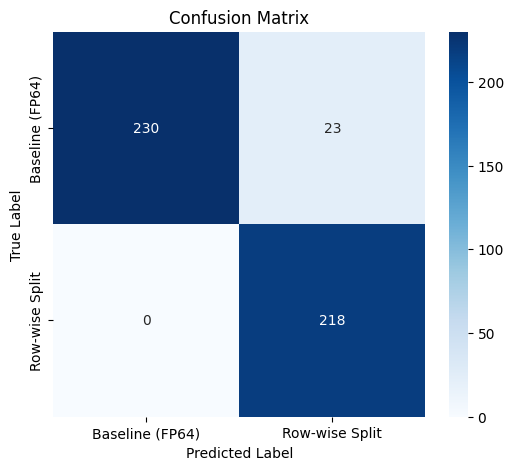


Raw Confusion Matrix:
[[230  23]
 [  0 218]]


In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Collect Predictions
model.eval()
all_preds = []
all_trues = []

print("Evaluating on Validation Set...")

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_trues.extend(yb.cpu().numpy())

# 2. Convert to Numpy
y_true = np.array(all_trues)
y_pred = np.array(all_preds)

# 3. Define Binary Class Names
target_names = ["Baseline (FP64)", "Row-wise Split"]

# 4. Generate Reports
print("\n" + "="*40)
print("FINAL CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

# 5. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

print("\nRaw Confusion Matrix:")
print(cm)

In [23]:
import scipy.sparse as sp
import scipy.io
import numpy as np

def load_matrix_metadata(m):
    """
    Robust loader: Handles both Sparse (Coordinate) and Dense (Array) .mtx files.
    """
    base_dir = data_dir / m.group / m.name

    if not base_dir.exists():
        # print(f"[WARN] Directory not found for {m.group}/{m.name}")
        return None

    # Recursively search for any .mtx file
    mtx_file = None
    for f in base_dir.rglob("*.mtx"):
        mtx_file = f
        break

    if mtx_file is None:
        return None

    try:
        # Load the matrix
        A = scipy.io.mmread(str(mtx_file))

        # --- FIX: Check if it's Dense (numpy) or Sparse ---
        if isinstance(A, np.ndarray):
            # It's a dense matrix -> Convert to Sparse CSR
            A = sp.csr_matrix(A)
        else:
            # It's already sparse -> Ensure CSR format
            A = A.tocsr()

        # Ensure correct data type (float64)
        A = A.astype(np.float64)

        return A

    except Exception as e:
        print(f"Error loading {m.group}/{m.name}: {e}")
        return None

print("Loader updated. Now re-run the Inference Test block.")

Loader updated. Now re-run the Inference Test block.


In [24]:
import torch
import numpy as np
import scipy.sparse as sp

# 1. Load the best model
model = PrecisionCNN(num_classes=2).to(device)
model.load_state_dict(torch.load("best_precision_cnn.pth"))
model.eval()

# 2. Define the Inference Pipeline
def predict_optimization(A_sparse):
    """
    Takes a SciPy sparse matrix, converts to image, and predicts the strategy.
    Returns:
        prediction (int): 0 (Baseline) or 1 (Row-wise)
        confidence (float): Probability of the predicted class
        class_name (str): Readable name
    """
    # Step A: Preprocess (Sparse -> Image)
    # Re-use the EXACT same function you used for training
    img = sparse_to_image(A_sparse, H=128, W=128)

    # Step B: Prepare Tensor (1, 1, 128, 128)
    # (Batch=1, Channel=1, H, W)
    img_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float().to(device)

    # Step C: Inference
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()

    names = ["Baseline (FP64)", "Row-wise Split (Optimized)"]
    return pred_idx, confidence, names[pred_idx]

# 3. Test on a few random matrices from our list
print("Running Live Inference Tests...")
print("-" * 60)

# We'll pick 3 random matrices to test
test_indices = np.random.choice(len(selected), 3, replace=False)

for idx in test_indices:
    m = selected[idx]
    A = load_matrix_metadata(m)
    if A is None: continue

    # Run Prediction
    pred, conf, name = predict_optimization(A)

    print(f"Matrix: {m.group}/{m.name}")
    print(f"  Shape: {A.shape}, NNZ: {A.nnz}")
    print(f"  AI Prediction: [{pred}] {name}")
    print(f"  Confidence:    {conf:.4f}")
    print("-" * 60)

Running Live Inference Tests...
------------------------------------------------------------
Matrix: VDOL/kineticBatchReactor_2
  Shape: (4361, 4361), NNZ: 44840
  AI Prediction: [0] Baseline (FP64)
  Confidence:    0.9731
------------------------------------------------------------
Matrix: HB/west0497
  Shape: (497, 497), NNZ: 1727
  AI Prediction: [0] Baseline (FP64)
  Confidence:    1.0000
------------------------------------------------------------
Matrix: Oberwolfach/t3dl_a
  Shape: (20360, 20360), NNZ: 509866
  AI Prediction: [1] Row-wise Split (Optimized)
  Confidence:    0.9998
------------------------------------------------------------
